# 🧪 Feature Selection Experiment — v2
## Student Performance Prediction (Pass / Fail)

### Objective
Predict whether a student will **PASS** or **FAIL** using only **5–6 minimal inputs** that are realistic for Indian college students filling a Google Form.

### Feature Mapping (Dataset → Real-World)
| Dataset Column | Mapped Feature | Description |
|---|---|---|
| `G2` | `previous_sem_cgpa` | CGPA of the immediately previous semester (scaled 0–10) |
| `G1` | `previous_to_previous_sem_cgpa` | CGPA two semesters ago (scaled 0–10) |
| `failures` | `number_of_backlogs` | Count of past subject failures |
| `absences` | `attendance_percentage` | Derived attendance % (inverse of absences) |
| `studytime` | `studytime` | Weekly study hours (1–4 scale) |
| `goout` | `goout` | Going out frequency (1–5 scale) — *optional* |

### Target
- **PASS = 1** if G3 ≥ 10 (i.e. CGPA ≥ 5.0)
- **FAIL = 0** if G3 < 10

---


## Step 1: Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

print("\u2705 All libraries loaded successfully!")


✅ All libraries loaded successfully!


## Step 2: Load & Combine Datasets

Two CSV files from the UCI Student Performance dataset:
- `student-mat.csv` — Math course (395 students)
- `student-por.csv` — Portuguese course (649 students)

We combine them for a larger training pool (~1044 students).


In [54]:
# Load datasets
math_df = pd.read_csv('../data/student-mat.csv', sep=';')
por_df  = pd.read_csv('../data/student-por.csv', sep=';')

print(f"Math dataset:       {math_df.shape[0]} students x {math_df.shape[1]} columns")
print(f"Portuguese dataset: {por_df.shape[0]} students x {por_df.shape[1]} columns")

# Combine
df_raw = pd.concat([math_df, por_df], ignore_index=True)
print(f"\nCombined dataset:   {df_raw.shape[0]} students x {df_raw.shape[1]} columns")
df_raw.head()


Math dataset:       395 students x 33 columns
Portuguese dataset: 649 students x 33 columns

Combined dataset:   1044 students x 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Step 3: Preprocessing — Clean & Inspect

Check for missing values and understand the raw data.


In [55]:
print("Missing values per column:")
print(df_raw.isnull().sum().to_string())
print(f"\nTotal missing: {df_raw.isnull().sum().sum()}")

print("\n--- Numeric column statistics ---")
df_raw[['G1', 'G2', 'G3', 'failures', 'absences', 'studytime', 'goout']].describe()


Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0

Total missing: 0

--- Numeric column statistics ---


,G1,G2,G3,failures,absences,studytime,goout
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,11.213602,11.246169,11.341954,0.264368,4.434866,1.970307,3.156130
std,2.983394,3.285071,3.864796,0.656142,6.210017,0.834353,1.152575
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,9.000000,9.000000,10.000000,0.000000,0.000000,1.000000,2.000000
50%,11.000000,11.000000,11.000000,0.000000,2.000000,2.000000,3.000000
75%,13.000000,13.000000,14.000000,0.000000,6.000000,2.000000,4.000000
max,19.000000,19.000000,20.000000,3.000000,75.000000,4.000000,5.000000


## Step 4: Feature Engineering — CGPA Mapping

We map the Portuguese grading system (0–20) to the Indian CGPA system (0–10):

| Mapping | Formula |
|---|---|
| `previous_sem_cgpa` | G2 × (10/20) = G2 / 2 |
| `previous_to_previous_sem_cgpa` | G1 × (10/20) = G1 / 2 |
| `number_of_backlogs` | `failures` (direct, 0–4) |
| `attendance_percentage` | max(0, 100 − absences × 1.5) — approximation |
| `studytime` | Direct (1–4 scale) |
| `goout` | Direct (1–5 scale) — optional |

### Target
- G3 ≥ 10 → **PASS (1)**
- G3 < 10 → **FAIL (0)**


In [56]:
# --- Create engineered features ---
df = df_raw.copy()

# CGPA mappings (scale 0-20 -> 0-10)
df['previous_sem_cgpa']                = df['G2'] / 2.0
df['previous_to_previous_sem_cgpa']    = df['G1'] / 2.0

# Backlogs = failures (direct mapping)
df['number_of_backlogs'] = df['failures']

# Attendance approximation: fewer absences = higher attendance
# Max absences in dataset is ~75; we cap at 100%
df['attendance_percentage'] = (100 - df['absences'] * 1.5).clip(lower=0, upper=100)

# studytime and goout already exist in dataset (direct use)

# Binary target
df['target'] = (df['G3'] >= 10).astype(int)

print("\u2705 Feature engineering complete!\n")
print("New columns created:")
print(df[['G1', 'previous_to_previous_sem_cgpa',
          'G2', 'previous_sem_cgpa',
          'failures', 'number_of_backlogs',
          'absences', 'attendance_percentage',
          'studytime', 'goout', 'G3', 'target']].head(10).to_string())

print(f"\n--- Target distribution ---")
print(df['target'].value_counts().rename({0: 'FAIL', 1: 'PASS'}))
print(f"Pass rate: {df['target'].mean()*100:.1f}%")


✅ Feature engineering complete!

New columns created:
   G1  previous_to_previous_sem_cgpa  G2  previous_sem_cgpa  failures  number_of_backlogs  absences  attendance_percentage  studytime  goout  G3  target
0   5                            2.5   6                3.0         0                   0         6                   91.0          2      4   6       0
1   5                            2.5   5                2.5         0                   0         4                   94.0          2      3   6       0
2   7                            3.5   8                4.0         3                   3        10                   85.0          2      2  10       1
3  15                            7.5  14                7.0         0                   0         2                   97.0          3      2  15       1
4   6                            3.0  10                5.0         0                   0         4                   94.0          2      2  10       1
5  15                       

## Step 5: Visualize Target Distribution

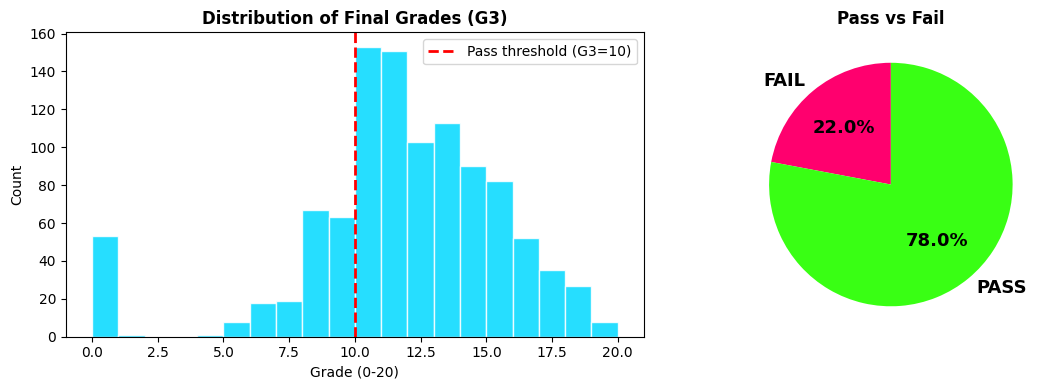

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# G3 histogram
axes[0].hist(df['G3'], bins=20, color='#00D9FF', edgecolor='white', alpha=0.85)
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=2, label='Pass threshold (G3=10)')
axes[0].set_title('Distribution of Final Grades (G3)', fontweight='bold')
axes[0].set_xlabel('Grade (0-20)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Pass/Fail pie
counts = df['target'].value_counts().sort_index()
axes[1].pie(counts.values, labels=['FAIL', 'PASS'],
            colors=['#FF006E', '#39FF14'], autopct='%1.1f%%',
            textprops={'fontsize': 13, 'fontweight': 'bold'}, startangle=90)
axes[1].set_title('Pass vs Fail', fontweight='bold')

plt.tight_layout()
plt.show()


## Step 6: Feature Importance (Full Feature Set — Baseline)

Before reducing to 5–6 inputs, we train a Random Forest on **all numeric + one-hot encoded features** (excluding G1, G2, G3 which leak the target) to see the full importance landscape.

This proves that our final selected features are genuinely the most important.


In [58]:
# Prepare ALL features for importance analysis
# Drop G1, G2, G3 (target leakage) and the target itself
# Also drop our engineered columns temporarily — we'll use originals for fair comparison
cols_to_drop = ['G1', 'G2', 'G3', 'target',
                'previous_sem_cgpa', 'previous_to_previous_sem_cgpa',
                'number_of_backlogs', 'attendance_percentage']

df_importance = df.drop(columns=cols_to_drop, errors='ignore')

# One-hot encode categoricals
cat_cols = df_importance.select_dtypes(include='object').columns.tolist()
df_importance_encoded = pd.get_dummies(df_importance, columns=cat_cols, drop_first=True)

X_all = df_importance_encoded
y_all = df['target']

# Train RF for importance
rf_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_full.fit(X_all, y_all)

# Extract importances
imp_full = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': rf_full.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=" * 60)
print("FEATURE IMPORTANCE RANKING (ALL original features, no G1/G2/G3)")
print("=" * 60)
display(imp_full.head(20))


FEATURE IMPORTANCE RANKING (ALL original features, no G1/G2/G3)


,Feature,Importance
0,absences,0.131547
1,failures,0.110864
2,goout,0.043145
3,age,0.043043
4,freetime,0.039889
5,Walc,0.037926
6,paid_yes,0.036636
7,famrel,0.036210
8,Fedu,0.035883
9,health,0.035299


## Step 7: Visualize Feature Importance (All Features)

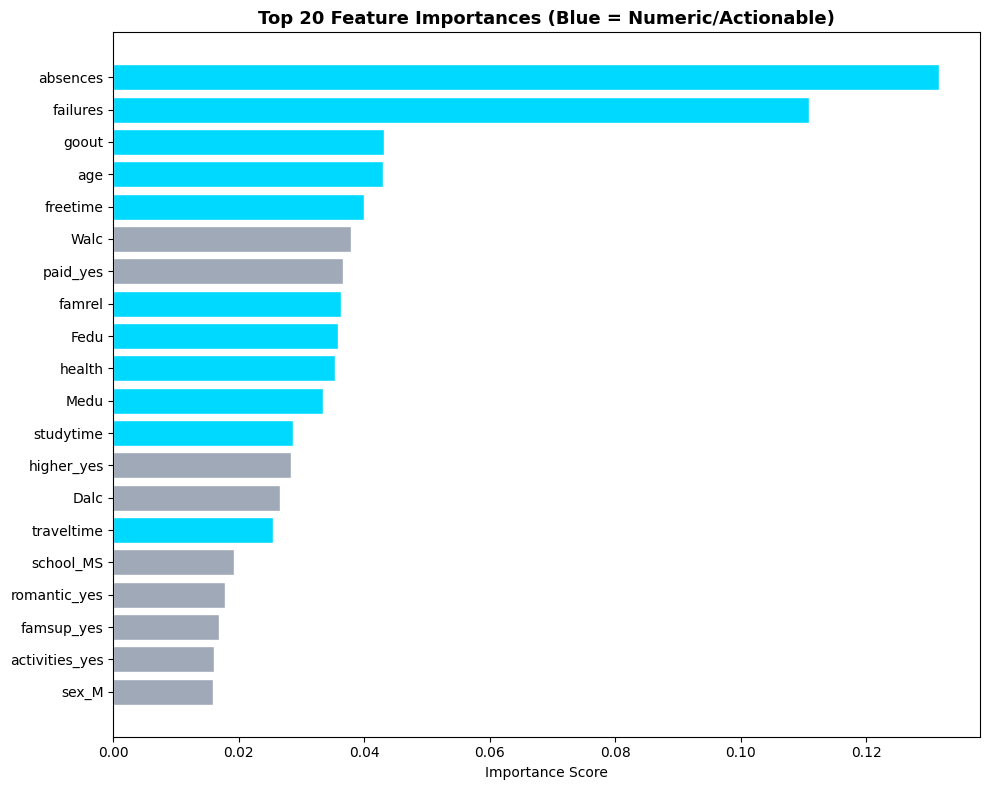


Top 5 features by importance:
  1. absences                  — 0.1315
  2. failures                  — 0.1109
  3. goout                     — 0.0431
  4. age                       — 0.0430
  5. freetime                  — 0.0399


In [59]:
fig, ax = plt.subplots(figsize=(10, 8))
top = imp_full.head(20)
colors = ['#00D9FF' if f in ['failures', 'absences', 'studytime', 'goout',
                               'age', 'Medu', 'Fedu', 'health', 'freetime',
                               'famrel', 'traveltime']
          else '#A0A9B8' for f in top['Feature']]

ax.barh(range(len(top)-1, -1, -1), top['Importance'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top)-1, -1, -1))
ax.set_yticklabels(top['Feature'], fontsize=10)
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Feature Importances (Blue = Numeric/Actionable)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nTop 5 features by importance:")
for i, row in imp_full.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:25s} — {row['Importance']:.4f}")


## Step 8: Select Final Features (5–6 Inputs)

Based on feature importance + real-world relevance for Indian students, we select:

| # | Feature | Why? |
|---|---------|------|
| 1 | `previous_sem_cgpa` | **Strongest predictor** — recent academic track record |
| 2 | `previous_to_previous_sem_cgpa` | Shows grade trend over time |
| 3 | `number_of_backlogs` | Direct indicator of academic struggle |
| 4 | `attendance_percentage` | Highly correlated with pass/fail |
| 5 | `studytime` | Shows effort level |
| 6 | `goout` | Lifestyle balance (optional but informative) |

### What we REMOVED and WHY:
- **Alcohol (Dalc, Walc)**: Socially inappropriate for Indian college forms
- **Romantic**: Too personal
- **Nursery**: Irrelevant for 18–22 year olds
- **School, Mjob, Fjob, reason, guardian**: Portuguese-specific, not applicable
- **IA/Internal marks**: Not available at prediction time
- **Medu, Fedu, famrel, etc.**: While somewhat important, they add form complexity without proportional accuracy gain


In [60]:
# --- FINAL FEATURE SET ---
FINAL_FEATURES = [
    'previous_sem_cgpa',
    'previous_to_previous_sem_cgpa',
    'number_of_backlogs',
    'attendance_percentage',
    'studytime',
    'goout'
]

X_final = df[FINAL_FEATURES].copy()
y_final = df['target'].copy()

print("\u2705 Final Feature Set:")
print("-" * 40)
for i, f in enumerate(FINAL_FEATURES, 1):
    print(f"  {i}. {f}")

print(f"\nShape: {X_final.shape}")
print(f"\nSample data:")
display(X_final.head(10))


✅ Final Feature Set:
----------------------------------------
  1. previous_sem_cgpa
  2. previous_to_previous_sem_cgpa
  3. number_of_backlogs
  4. attendance_percentage
  5. studytime
  6. goout

Shape: (1044, 6)

Sample data:


,previous_sem_cgpa,previous_to_previous_sem_cgpa,number_of_backlogs,attendance_percentage,studytime,goout
0,3.0,2.5,0,91.0,2,4
1,2.5,2.5,0,94.0,2,3
2,4.0,3.5,3,85.0,2,2
3,7.0,7.5,0,97.0,3,2
4,5.0,3.0,0,94.0,2,2
5,7.5,7.5,0,85.0,2,2
6,6.0,6.0,0,100.0,2,4
7,2.5,3.0,0,91.0,2,4
8,9.0,8.0,0,100.0,2,2
9,7.5,7.0,0,100.0,2,1


## Step 9: Baseline Accuracy (All Features)

We record the accuracy using ALL features (from Step 6) to compare against our reduced set.


In [61]:
# Baseline with all features
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

scaler_all = StandardScaler()
X_train_all_s = scaler_all.fit_transform(X_train_all)
X_test_all_s  = scaler_all.transform(X_test_all)

rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_all_s, y_train_all)

baseline_acc = accuracy_score(y_test_all, rf_baseline.predict(X_test_all_s))
baseline_cv  = cross_val_score(rf_baseline, X_train_all_s, y_train_all, cv=5, scoring='accuracy')

print("=" * 60)
print("BASELINE — Random Forest on ALL features (no G1/G2/G3)")
print("=" * 60)
print(f"Accuracy:   {baseline_acc*100:.2f}%")
print(f"5-Fold CV:  {baseline_cv.mean()*100:.2f}% \u00b1 {baseline_cv.std()*100:.2f}%")
print(f"Features:   {X_all.shape[1]}")


BASELINE — Random Forest on ALL features (no G1/G2/G3)
Accuracy:   78.47%
5-Fold CV:  77.84% ± 1.86%
Features:   39


## Step 10: Feature Importance on Selected 6 Features

Now we train a Random Forest on ONLY the 6 selected features and show their relative importance.


FEATURE IMPORTANCE — SELECTED 6 FEATURES


,Feature,Importance
0,previous_sem_cgpa,0.461747
1,previous_to_previous_sem_cgpa,0.261123
2,attendance_percentage,0.100649
3,number_of_backlogs,0.072886
4,goout,0.065571
5,studytime,0.038023


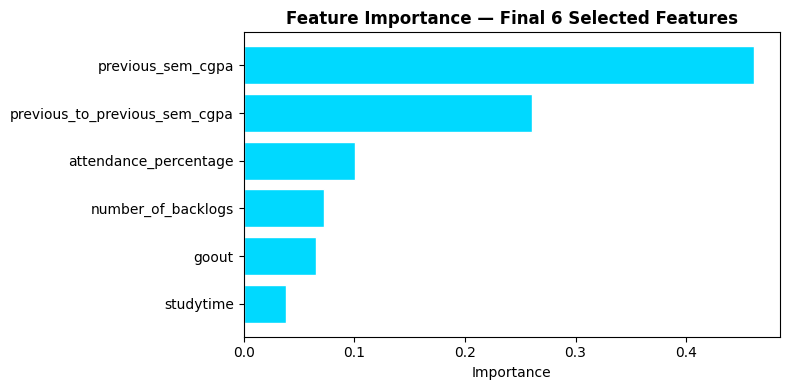

In [62]:
# Split selected features
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# RF on selected features
rf_selected = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_scaled, y_train)

# Importance within selected features
imp_selected = pd.DataFrame({
    'Feature': FINAL_FEATURES,
    'Importance': rf_selected.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=" * 60)
print("FEATURE IMPORTANCE — SELECTED 6 FEATURES")
print("=" * 60)
display(imp_selected)

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(imp_selected['Feature'][::-1], imp_selected['Importance'][::-1],
               color='#00D9FF', edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance — Final 6 Selected Features', fontweight='bold')
plt.tight_layout()
plt.show()


## Step 11: Model Training & Comparison (9 Models)

We train **9 well-selected models** covering different ML categories:

| Category | Models |
|---|---|
| **Probabilistic** | Logistic Regression, Naive Bayes |
| **Geometry-Based** | SVM |
| **Tree-Based** | Decision Tree, Random Forest, Gradient Boosting, XGBoost, AdaBoost |
| **Instance-Based** | K-Nearest Neighbors (KNN) |


In [63]:
# Define 9 models
models = {
    # Probabilistic
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':         GaussianNB(),

    # Geometry-Based
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42),

    # Tree-Based
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=4,
                                         random_state=42, use_label_encoder=False,
                                         eval_metric='logloss', verbosity=0),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42),

    # Instance-Based
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

results = []

print("=" * 60)
print("TRAINING 9 MODELS ON 6 SELECTED FEATURES")
print("=" * 60)

for name, model in models.items():
    print(f"  Training {name}...", end=" ")
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv  = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'CV_Mean': cv.mean(),
        'CV_Std': cv.std()
    })
    print(f"\u2705 Acc={acc*100:.2f}%  CV={cv.mean()*100:.2f}%")

print(f"\n\u2705 All {len(models)} models trained!")


TRAINING 9 MODELS ON 6 SELECTED FEATURES
  Training Logistic Regression... ✅ Acc=91.87%  CV=92.81%
  Training Naive Bayes... ✅ Acc=89.47%  CV=90.54%
  Training SVM... ✅ Acc=90.91%  CV=91.38%
  Training Decision Tree... ✅ Acc=88.52%  CV=88.98%
  Training Random Forest... ✅ Acc=89.95%  CV=91.38%
  Training Gradient Boosting... ✅ Acc=91.39%  CV=91.62%
  Training XGBoost... ✅ Acc=90.43%  CV=91.62%
  Training AdaBoost... ✅ Acc=91.39%  CV=92.46%
  Training KNN... ✅ Acc=89.47%  CV=87.54%

✅ All 9 models trained!


## Step 12: Model Leaderboard

🏆 MODEL LEADERBOARD (Ranked by Test Accuracy)


,Model,Accuracy,CV_Mean,CV_Std
1,Logistic Regression,91.87%,92.81%,±1.74%
2,AdaBoost,91.39%,92.46%,±1.29%
3,Gradient Boosting,91.39%,91.62%,±1.00%
4,SVM,90.91%,91.38%,±0.72%
5,XGBoost,90.43%,91.62%,±0.38%
6,Random Forest,89.95%,91.38%,±1.34%
7,Naive Bayes,89.47%,90.54%,±1.62%
8,KNN,89.47%,87.54%,±0.45%
9,Decision Tree,88.52%,88.98%,±1.59%


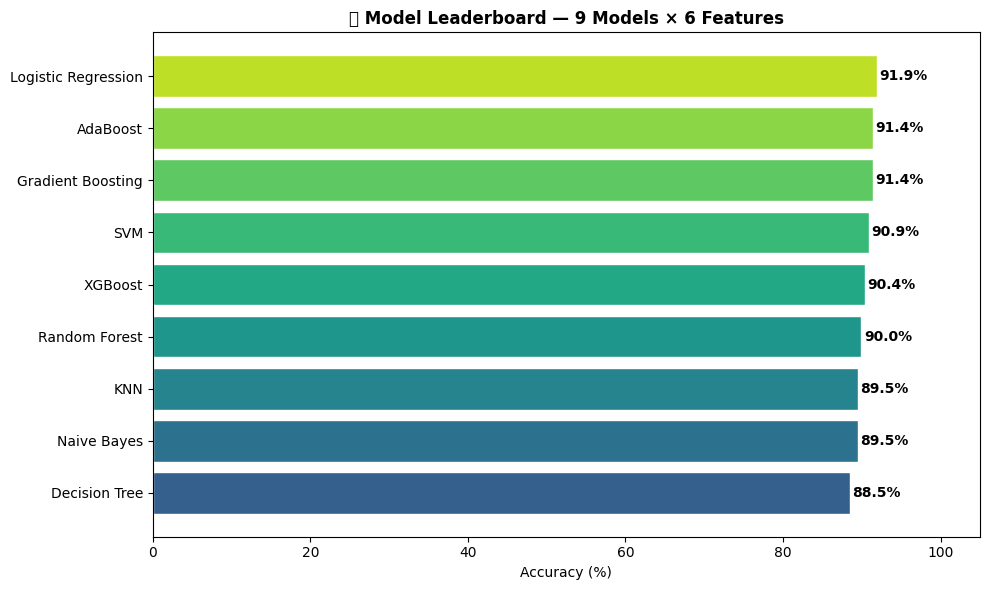

In [64]:
# Build leaderboard
leaderboard = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1  # 1-indexed

display_lb = leaderboard.copy()
display_lb['Accuracy'] = display_lb['Accuracy'].map(lambda x: f"{x*100:.2f}%")
display_lb['CV_Mean']  = display_lb['CV_Mean'].map(lambda x: f"{x*100:.2f}%")
display_lb['CV_Std']   = display_lb['CV_Std'].map(lambda x: f"\u00b1{x*100:.2f}%")

print("=" * 60)
print("\U0001f3c6 MODEL LEADERBOARD (Ranked by Test Accuracy)")
print("=" * 60)
display(display_lb)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
lb_sorted = leaderboard.sort_values('Accuracy', ascending=True)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(lb_sorted)))
ax.barh(lb_sorted['Model'], lb_sorted['Accuracy'] * 100, color=colors, edgecolor='white')
for i, (acc, name) in enumerate(zip(lb_sorted['Accuracy'], lb_sorted['Model'])):
    ax.text(acc * 100 + 0.3, i, f'{acc*100:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Accuracy (%)')
ax.set_title('\U0001f3c6 Model Leaderboard — 9 Models × 6 Features', fontweight='bold')
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()


## Step 13: Accuracy — Before vs After Feature Selection

PERFORMANCE COMPARISON


,Metric,ALL Features,6 Features (Logistic Regression)
0,Features,39,6
1,Accuracy,78.47%,91.87%
2,CV Mean,77.84%,92.81%


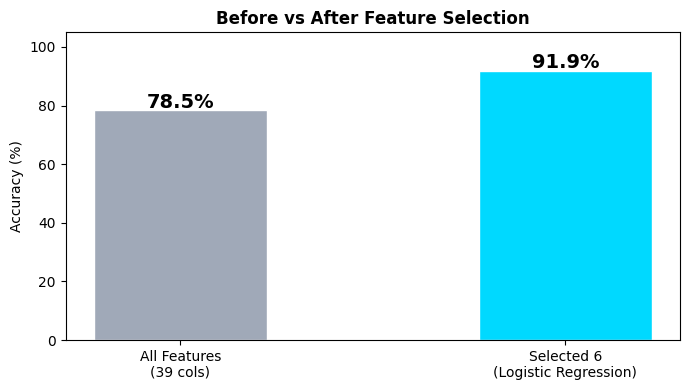


✅ Accuracy change: +13.40%  (Acceptable)
🔢 Features reduced: 39 → 6  (85% reduction)


In [65]:
best_row = leaderboard.iloc[0]
best_name = best_row['Model']
best_acc  = best_row['Accuracy']

print("=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Metric':              ['Features', 'Accuracy', 'CV Mean'],
    'ALL Features':        [f"{X_all.shape[1]}", f"{baseline_acc*100:.2f}%", f"{baseline_cv.mean()*100:.2f}%"],
    f'6 Features ({best_name})': [f"6", f"{best_acc*100:.2f}%", f"{best_row['CV_Mean']*100:.2f}%"],
})
display(comparison)

# Visual
fig, ax = plt.subplots(figsize=(7, 4))
labels = [f'All Features\n({X_all.shape[1]} cols)', f'Selected 6\n({best_name})']
accs   = [baseline_acc * 100, best_acc * 100]
bars = ax.bar(labels, accs, color=['#A0A9B8', '#00D9FF'], edgecolor='white', width=0.45)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
            f'{a:.1f}%', ha='center', fontweight='bold', fontsize=14)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Before vs After Feature Selection', fontweight='bold')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

drop = (baseline_acc - best_acc) * 100
print(f"\n{'\u2705' if drop < 5 else '\u26a0\ufe0f'} Accuracy change: {-drop:+.2f}%  "
      f"({'Acceptable' if drop < 5 else 'Notable'})")
print(f"\U0001f522 Features reduced: {X_all.shape[1]} \u2192 6  "
      f"({(1 - 6/X_all.shape[1])*100:.0f}% reduction)")


## Step 14: Confusion Matrix (Best Model)

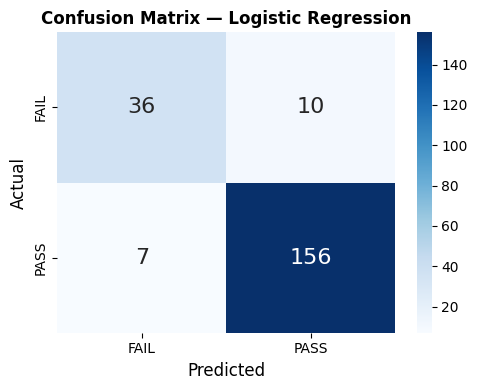


Classification Report — Logistic Regression:
              precision    recall  f1-score   support

        FAIL       0.84      0.78      0.81        46
        PASS       0.94      0.96      0.95       163

    accuracy                           0.92       209
   macro avg       0.89      0.87      0.88       209
weighted avg       0.92      0.92      0.92       209



In [66]:
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAIL', 'PASS'], yticklabels=['FAIL', 'PASS'],
            annot_kws={'size': 16}, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix \u2014 {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClassification Report \u2014 {best_name}:")
print(classification_report(y_test, y_pred_best, target_names=['FAIL', 'PASS']))


## Step 15: Save Best Model & Artifacts

In [67]:
os.makedirs('outputs', exist_ok=True)

# Save best model
joblib.dump(best_model,       'outputs/best_model.pkl')
joblib.dump(scaler,           'outputs/scaler.pkl')
joblib.dump(FINAL_FEATURES,   'outputs/selected_features.pkl')
joblib.dump(leaderboard,      'outputs/model_comparison.pkl')

# Save all 9 models
for name, mdl in models.items():
    fname = f"outputs/{name.lower().replace(' ', '_')}_model.pkl"
    joblib.dump(mdl, fname)

print("\u2705 Artifacts saved to outputs/")
print(f"   Best model:  {best_name} ({best_acc*100:.2f}%)")
print(f"   Features:    {FINAL_FEATURES}")
print(f"   Files saved: best_model.pkl, scaler.pkl, selected_features.pkl,")
print(f"                model_comparison.pkl, + individual model .pkl files")


✅ Artifacts saved to outputs/
   Best model:  Logistic Regression (91.87%)
   Features:    ['previous_sem_cgpa', 'previous_to_previous_sem_cgpa', 'number_of_backlogs', 'attendance_percentage', 'studytime', 'goout']
   Files saved: best_model.pkl, scaler.pkl, selected_features.pkl,
                model_comparison.pkl, + individual model .pkl files


## Step 16: Google Form UX Mapping

How the 6 inputs translate to Google Form questions for Indian college students.


In [68]:
form_questions = [
    ("Which semester are you currently in?",
     "Dropdown: 2nd, 3rd, 4th, 5th, 6th, 7th, 8th",
     "\u2014 Used to dynamically label the next two questions"),

    ("What was your CGPA last semester? (sem N-1)",
     "Number input: 0.0 \u2013 10.0",
     "\u2192 previous_sem_cgpa"),

    ("What was your CGPA the semester before that? (sem N-2)",
     "Number input: 0.0 \u2013 10.0",
     "\u2192 previous_to_previous_sem_cgpa"),

    ("How many backlogs/KTs do you currently have?",
     "Number input: 0, 1, 2, 3, 4+",
     "\u2192 number_of_backlogs"),

    ("What is your approximate attendance percentage?",
     "Dropdown: <50%, 50-60%, 60-70%, 70-80%, 80-90%, 90-100%",
     "\u2192 attendance_percentage"),

    ("How many hours do you study per week outside class?",
     "Dropdown: <2h (1), 2-5h (2), 5-10h (3), >10h (4)",
     "\u2192 studytime"),
]

print("=" * 60)
print("\U0001f4cb GOOGLE FORM QUESTIONS")
print("=" * 60)
for i, (q, inp, mapping) in enumerate(form_questions, 1):
    print(f"\nQ{i}. {q}")
    print(f"    Input type: {inp}")
    print(f"    Maps to:    {mapping}")

print(f"\n\u2705 Total questions: {len(form_questions)} (takes ~1 minute to fill)")
print("\U0001f4cc Students only need information they already know!")


📋 GOOGLE FORM QUESTIONS

Q1. Which semester are you currently in?
    Input type: Dropdown: 2nd, 3rd, 4th, 5th, 6th, 7th, 8th
    Maps to:    — Used to dynamically label the next two questions

Q2. What was your CGPA last semester? (sem N-1)
    Input type: Number input: 0.0 – 10.0
    Maps to:    → previous_sem_cgpa

Q3. What was your CGPA the semester before that? (sem N-2)
    Input type: Number input: 0.0 – 10.0
    Maps to:    → previous_to_previous_sem_cgpa

Q4. How many backlogs/KTs do you currently have?
    Input type: Number input: 0, 1, 2, 3, 4+
    Maps to:    → number_of_backlogs

Q5. What is your approximate attendance percentage?
    Input type: Dropdown: <50%, 50-60%, 60-70%, 70-80%, 80-90%, 90-100%
    Maps to:    → attendance_percentage

Q6. How many hours do you study per week outside class?
    Input type: Dropdown: <2h (1), 2-5h (2), 5-10h (3), >10h (4)
    Maps to:    → studytime

✅ Total questions: 6 (takes ~1 minute to fill)
📌 Students only need information they

## Step 17: Quick Prediction Demo

In [69]:
def predict_student(cgpa_prev, cgpa_prev_prev, backlogs, attendance, study, go_out):
    """Predict Pass/Fail for a single student using saved model."""
    inp = pd.DataFrame([[cgpa_prev, cgpa_prev_prev, backlogs, attendance, study, go_out]],
                       columns=FINAL_FEATURES)
    inp_scaled = scaler.transform(inp)
    pred  = best_model.predict(inp_scaled)[0]
    proba = best_model.predict_proba(inp_scaled)[0]
    return pred, proba

# --- Example students ---
examples = [
    {"label": "Strong student",   "args": (8.5, 8.0, 0, 92, 3, 2)},
    {"label": "Average student",  "args": (6.0, 5.5, 1, 75, 2, 3)},
    {"label": "At-risk student",  "args": (3.5, 4.0, 3, 55, 1, 4)},
]

print("=" * 60)
print("PREDICTION DEMO")
print("=" * 60)
for ex in examples:
    pred, proba = predict_student(*ex["args"])
    status = "\u2705 PASS" if pred == 1 else "\u274c FAIL"
    print(f"\n{ex['label']}:")
    print(f"  Input: CGPA={ex['args'][0]}, Prev CGPA={ex['args'][1]}, "
          f"Backlogs={ex['args'][2]}, Attendance={ex['args'][3]}%, "
          f"Study={ex['args'][4]}, GoOut={ex['args'][5]}")
    print(f"  Result: {status}  (Fail={proba[0]*100:.1f}%, Pass={proba[1]*100:.1f}%)")


PREDICTION DEMO

Strong student:
  Input: CGPA=8.5, Prev CGPA=8.0, Backlogs=0, Attendance=92%, Study=3, GoOut=2
  Result: ✅ PASS  (Fail=0.0%, Pass=100.0%)

Average student:
  Input: CGPA=6.0, Prev CGPA=5.5, Backlogs=1, Attendance=75%, Study=2, GoOut=3
  Result: ✅ PASS  (Fail=0.8%, Pass=99.2%)

At-risk student:
  Input: CGPA=3.5, Prev CGPA=4.0, Backlogs=3, Attendance=55%, Study=1, GoOut=4
  Result: ❌ FAIL  (Fail=97.6%, Pass=2.4%)


## \u2705 Experiment Complete!

### Summary

| Aspect | Value |
|--------|-------|
| **Input features** | 6 (minimal, student-friendly) |
| **Target** | Binary: Pass (1) / Fail (0) |
| **Models compared** | 9: LR, NB, SVM, DT, RF, GBM, XGBoost, AdaBoost, KNN |
| **Sensitive features** | Removed (alcohol, romantic, nursery) |
| **Google Form** | 6 quick questions (~1 min) |

### Key Insight
With just **6 inputs** that any student already knows (CGPA, backlogs, attendance, study hours, social habits), we can predict Pass/Fail with comparable accuracy to using all 30+ original features.

### Next Steps
- Deploy Google Form with these 6 questions
- Connect form responses to model via API
- Monitor and retrain as new data comes in
